In [2]:
import pandas as pd
df = pd.read_csv("/workspaces/Daegun26Veritas/data/penguins.csv")
df.head(345)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female
...,...,...,...,...,...,...,...
339,Chinstrap,Dream,55.8,19.8,207.0,4000.0,male
340,Chinstrap,Dream,43.5,18.1,202.0,3400.0,female
341,Chinstrap,Dream,49.6,18.2,193.0,3775.0,male
342,Chinstrap,Dream,50.8,19.0,210.0,4100.0,male


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


<Axes: xlabel='species', ylabel='count'>

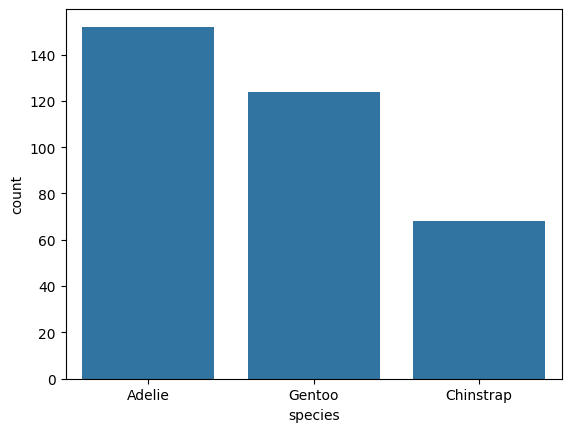

In [5]:
import seaborn as sns
sns.countplot(x=df['species'])

In [6]:
df.isnull().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
df=df.dropna(axis=0)
df.shape

(333, 7)

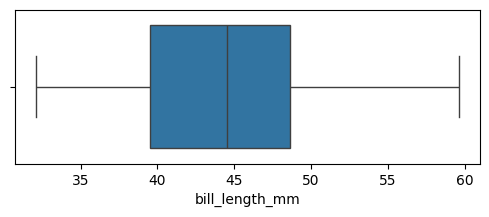

In [8]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,2))
sns.boxplot(data=df, x='bill_length_mm')
plt.show()

In [9]:
df['species'].unique()

array(['Adelie', 'Gentoo', 'Chinstrap'], dtype=object)

In [10]:
df['sex'].unique()

array(['male', 'female'], dtype=object)

In [11]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']] = scaler.fit_transform(df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']])
df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,0.254545,0.666667,0.152542,0.291667,male
1,Adelie,Torgersen,0.269091,0.511905,0.237288,0.305556,female
2,Adelie,Torgersen,0.298182,0.583333,0.389831,0.152778,female
4,Adelie,Torgersen,0.167273,0.738095,0.355932,0.208333,female
5,Adelie,Torgersen,0.261818,0.892857,0.305085,0.263889,male
6,Adelie,Torgersen,0.247273,0.559524,0.152542,0.256944,female
7,Adelie,Torgersen,0.258182,0.773810,0.389831,0.548611,male
12,Adelie,Torgersen,0.327273,0.535714,0.169492,0.138889,female
13,Adelie,Torgersen,0.236364,0.964286,0.322034,0.305556,male
14,Adelie,Torgersen,0.090909,0.952381,0.440678,0.472222,male


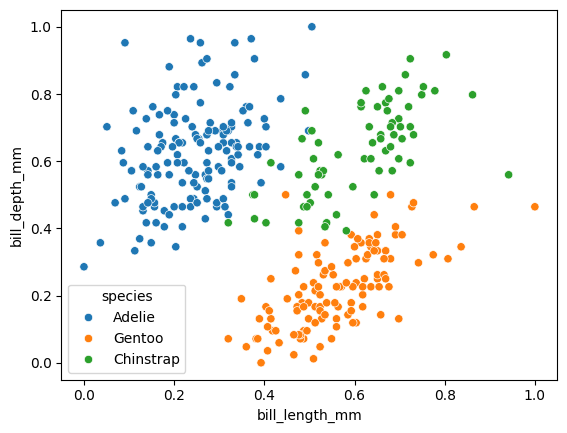

In [12]:
sns.scatterplot(x='bill_length_mm',y='bill_depth_mm',hue='species',data=df)
plt.show()

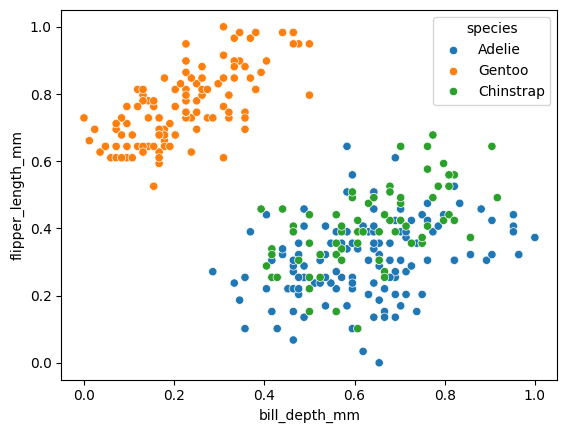

In [13]:
sns.scatterplot(y='flipper_length_mm',x='bill_depth_mm',hue='species',data=df)
plt.show()

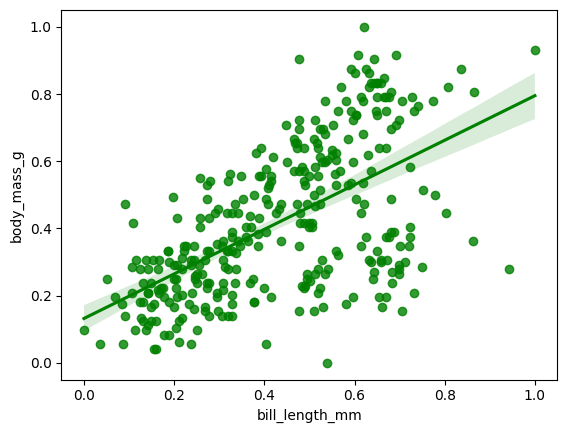

In [14]:
sns.regplot(x='bill_length_mm',y='body_mass_g',data=df,color='g')
plt.show()

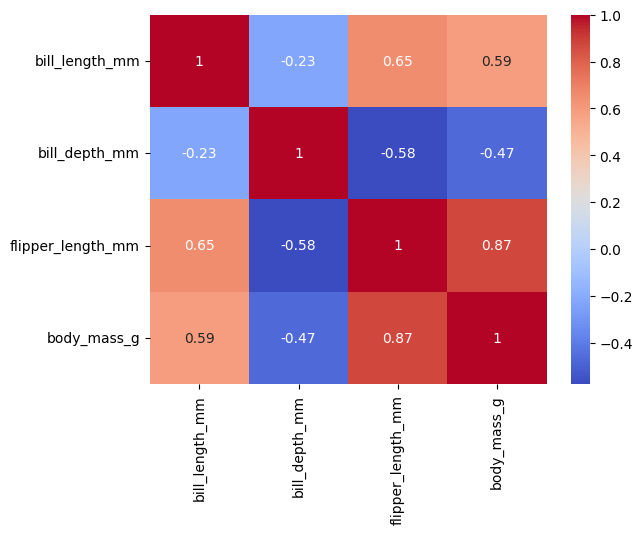

In [15]:
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.show()

In [16]:
X=df[['bill_length_mm','bill_depth_mm','flipper_length_mm','body_mass_g']]
y=df['species']
X.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,0.254545,0.666667,0.152542,0.291667
1,0.269091,0.511905,0.237288,0.305556
2,0.298182,0.583333,0.389831,0.152778
4,0.167273,0.738095,0.355932,0.208333
5,0.261818,0.892857,0.305085,0.263889


# **결정트리**

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y)

In [18]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)

print(dt.score(X_train, y_train))
print(dt.score(X_test,y_test))

1.0
0.96


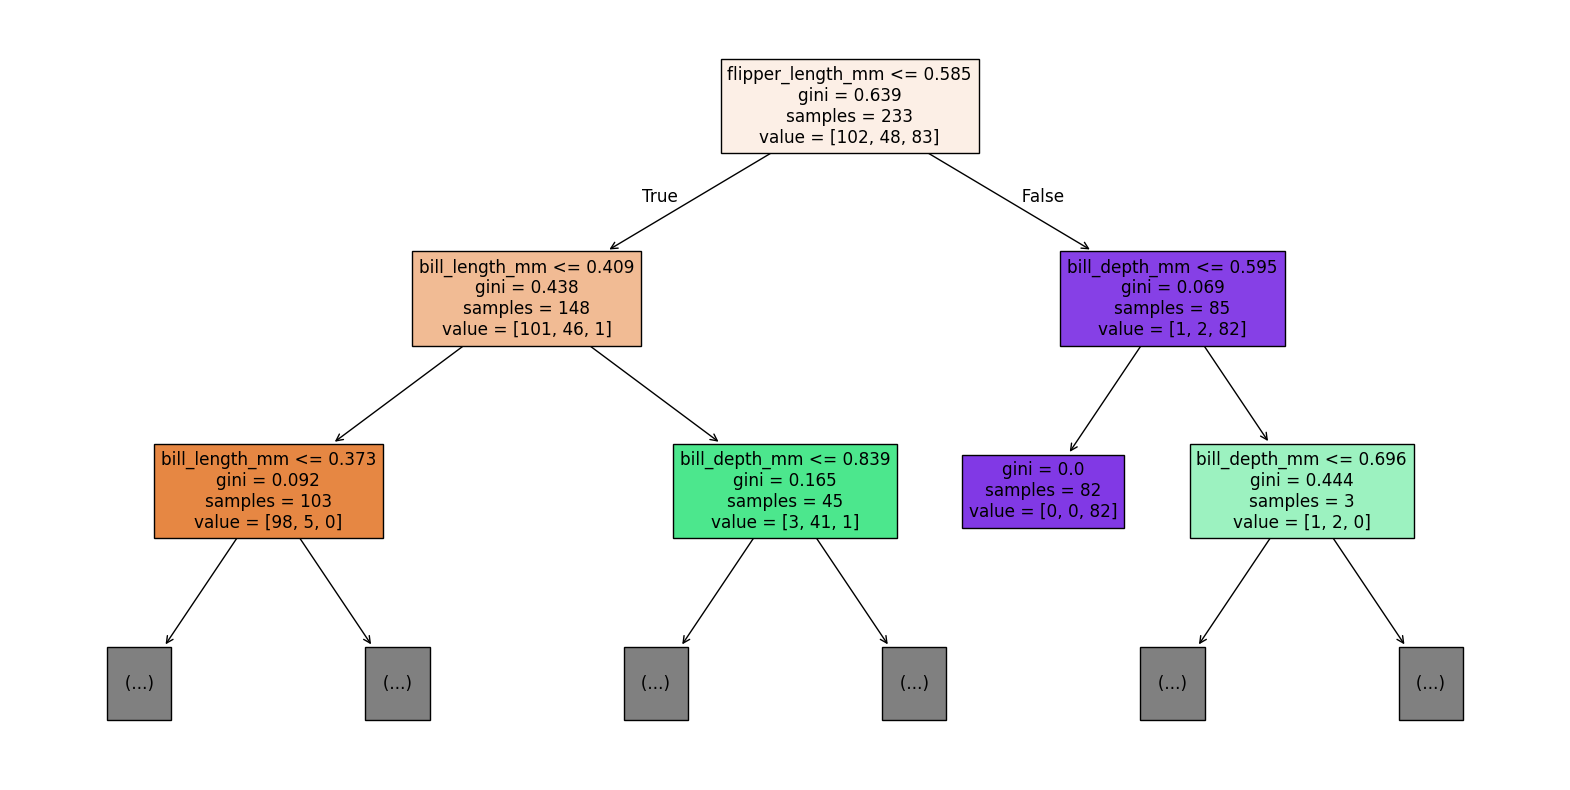

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(dt,filled=True,feature_names=X.columns,max_depth=2)
plt.show()

In [20]:
dt_pred = dt.predict(X_test)
print(f'결정트리: {dt.score(X_test,y_test)}')

결정트리: 0.96


# **로지스틱**

In [21]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [22]:
lr_pred = lr.predict(X_test)
print(f'로지스틱: {lr.score(X_test,y_test)}')

로지스틱: 0.99


# **KNN**

In [23]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [24]:
knn_pred = knn.predict(X_test)
print(f'KNN: {knn.score(X_test,y_test)}')

KNN: 1.0


In [25]:
for k in range(2,11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = knn.score(X_test,y_test)
    print(f'k: {k}, accuracy: {score}')

k: 2, accuracy: 0.97
k: 3, accuracy: 0.99


k: 4, accuracy: 1.0
k: 5, accuracy: 1.0
k: 6, accuracy: 1.0
k: 7, accuracy: 1.0
k: 8, accuracy: 1.0
k: 9, accuracy: 1.0
k: 10, accuracy: 1.0


# **혼동행렬**

In [26]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def cm(x):
    conf = confusion_matrix(y_test, x)
    sns.heatmap(conf,annot=True,cmap='Blues')
    plt.title(f"Penguin Classification")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

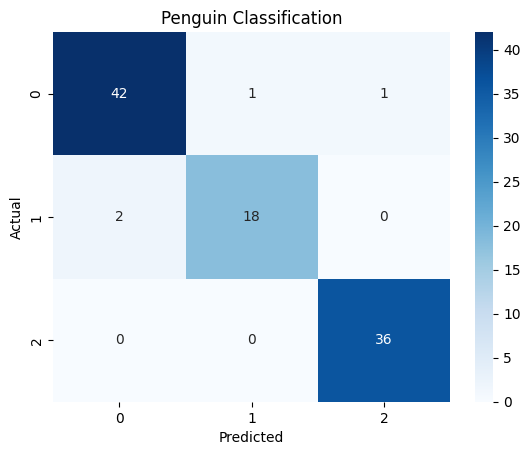

In [27]:
cm(dt_pred)

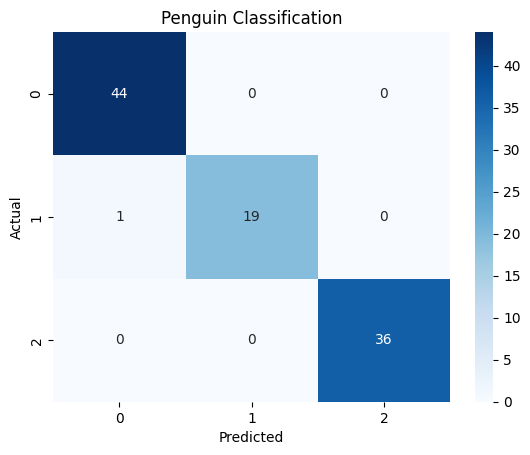

In [28]:
cm(lr_pred)

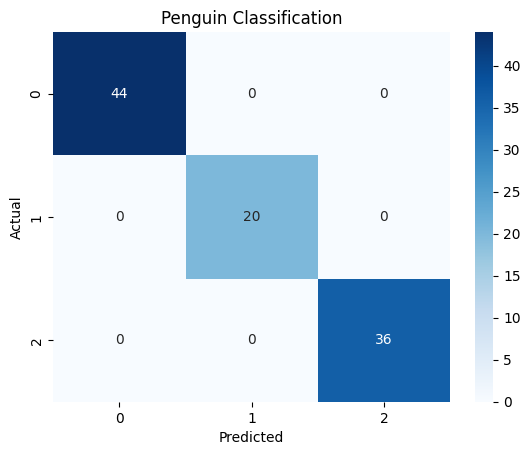

In [29]:
cm(knn_pred)